<a href="https://colab.research.google.com/github/ibrahimbarghout/robust-ecg-domain-generalization/blob/main/notebooks/08_ECG_Signal_Preprocessing%2Cipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# 08 — ECG Signal Preprocessing & Preparation
# Cell 01 — Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [4]:
# ============================================================
# Cell 02A — Install WFDB
# ============================================================

!pip install wfdb -q

print("WFDB installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.9 MB/s eta 0:00:00
WFDB installed successfully.


In [5]:
# ============================================================
# Cell 02 — Imports
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

from scipy import signal

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
# ============================================================
# Cell 03 — Project paths
# ============================================================

PROJECT_PATH = "/content/drive/MyDrive/PTB-XL Research Project"

DATA_PATH = os.path.join(
    PROJECT_PATH,
    "data",
    "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
)

RESULTS_PATH = os.path.join(
    PROJECT_PATH,
    "results"
)

print("Dataset path:")
print(DATA_PATH)
print("Dataset exists:", os.path.exists(DATA_PATH))

print("\nResults path:")
print(RESULTS_PATH)
print("Results directory exists:", os.path.exists(RESULTS_PATH))

Dataset path:
/content/drive/MyDrive/PTB-XL Research Project/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3
Dataset exists: True

Results path:
/content/drive/MyDrive/PTB-XL Research Project/results
Results directory exists: True


In [7]:
# ============================================================
# Cell 04 — Load Metadata, Targets, Demographic Data & Split
# ============================================================

metadata_path = os.path.join(DATA_PATH, "ptbxl_database.csv")

targets_path = os.path.join(
    RESULTS_PATH,
    "ptbxl_diagnostic_targets.csv"
)

demographics_path = os.path.join(
    RESULTS_PATH,
    "ptbxl_cleaned_demographics.csv"
)

split_path = os.path.join(
    RESULTS_PATH,
    "ptbxl_patient_independent_split.csv"
)

# Load files
df = pd.read_csv(metadata_path, index_col="ecg_id")
targets = pd.read_csv(targets_path, index_col="ecg_id")
demographics_clean = pd.read_csv(demographics_path, index_col="ecg_id")
split_df = pd.read_csv(split_path, index_col="ecg_id")

print("Metadata shape:", df.shape)
print("Targets shape:", targets.shape)
print("Demographics shape:", demographics_clean.shape)
print("Split shape:", split_df.shape)

print("\nAll files loaded successfully.")

Metadata shape: (21799, 27)
Targets shape: (21799, 7)
Demographics shape: (21799, 8)
Split shape: (21799, 3)

All files loaded successfully.


In [8]:
# ============================================================
# Cell 05 — Verify ECG ID Alignment
# ============================================================

metadata_ids = set(df.index)
target_ids = set(targets.index)
demographic_ids = set(demographics_clean.index)
split_ids = set(split_df.index)

print("Metadata IDs      :", len(metadata_ids))
print("Target IDs        :", len(target_ids))
print("Demographic IDs   :", len(demographic_ids))
print("Split IDs         :", len(split_ids))

print("\nAlignment checks:")

print(
    "Metadata ↔ Targets:",
    metadata_ids == target_ids
)

print(
    "Metadata ↔ Demographics:",
    metadata_ids == demographic_ids
)

print(
    "Metadata ↔ Split:",
    metadata_ids == split_ids
)

# Check for duplicates
print("\nDuplicate ECG IDs:")
print("Metadata     :", df.index.duplicated().sum())
print("Targets      :", targets.index.duplicated().sum())
print("Demographics :", demographics_clean.index.duplicated().sum())
print("Split        :", split_df.index.duplicated().sum())

Metadata IDs      : 21799
Target IDs        : 21799
Demographic IDs   : 21799
Split IDs         : 21799

Alignment checks:
Metadata ↔ Targets: True
Metadata ↔ Demographics: True
Metadata ↔ Split: True

Duplicate ECG IDs:
Metadata     : 0
Targets      : 0
Demographics : 0
Split        : 0


In [9]:
# ============================================================
# Cell 06 — Verify Patient-Independent Split
# ============================================================

# Combine split information with patient IDs
split_check = df[["patient_id"]].join(
    split_df[["split"]],
    how="inner"
)

print("ECGs per split:")
print(split_check["split"].value_counts())

print("\nUnique patients per split:")
print(
    split_check.groupby("split")["patient_id"]
    .nunique()
)

# Check patient overlap between splits
train_patients = set(
    split_check.loc[
        split_check["split"] == "train",
        "patient_id"
    ]
)

validation_patients = set(
    split_check.loc[
        split_check["split"] == "validation",
        "patient_id"
    ]
)

test_patients = set(
    split_check.loc[
        split_check["split"] == "test",
        "patient_id"
    ]
)

print("\nPatient overlap:")
print("Train ∩ Validation:", len(train_patients & validation_patients))
print("Train ∩ Test:", len(train_patients & test_patients))
print("Validation ∩ Test:", len(validation_patients & test_patients))

ECGs per split:
split
train         17418
test           2198
validation     2183
Name: count, dtype: int64

Unique patients per split:
split
test           1904
train         15023
validation     1942
Name: patient_id, dtype: int64

Patient overlap:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [10]:
# ============================================================
# Cell 07 — Select Representative ECG
# ============================================================

ecg_id = 39

filename_hr = df.loc[ecg_id, "filename_hr"]

record_path = os.path.join(
    DATA_PATH,
    filename_hr
)

print("Selected ECG:", ecg_id)
print("High-resolution record:")
print(record_path)

print("\nRecord files:")
print("Header exists:", os.path.exists(record_path + ".hea"))
print("Signal exists:", os.path.exists(record_path + ".dat"))

print("\nDiagnostic targets:")
print(targets.loc[ecg_id].to_dict())

print("\nSplit:")
print(split_df.loc[ecg_id, "split"])

Selected ECG: 39
High-resolution record:
/content/drive/MyDrive/PTB-XL Research Project/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records500/00000/00039_hr

Record files:
Header exists: True
Signal exists: True

Diagnostic targets:
{'NORM': 0, 'MI': 1, 'STTC': 1, 'CD': 0, 'HYP': 0, 'ABNORMAL': 1, 'REFERENCE_NORMAL': 0}

Split:
validation


In [11]:
# ============================================================
# Cell 08 — Load Raw High-Resolution ECG
# ============================================================

record = wfdb.rdrecord(record_path)

ecg_signal = record.p_signal
sampling_frequency = record.fs
lead_names = record.sig_name

print("ECG ID:", ecg_id)
print("Sampling frequency:", sampling_frequency, "Hz")
print("Number of samples:", ecg_signal.shape[0])
print("Number of leads:", ecg_signal.shape[1])
print("Duration:", ecg_signal.shape[0] / sampling_frequency, "seconds")

print("\nSignal shape:")
print(ecg_signal.shape)

print("\nLead names:")
print(lead_names)

print("\nUnits:")
print(record.units)

ECG ID: 39
Sampling frequency: 500 Hz
Number of samples: 5000
Number of leads: 12
Duration: 10.0 seconds

Signal shape:
(5000, 12)

Lead names:
['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

Units:
['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV']


In [12]:
# ============================================================
# Cell 09 — Raw Signal Integrity Check
# ============================================================

print("ECG ID:", ecg_id)
print("=" * 70)

# Check for invalid values
nan_count = np.isnan(ecg_signal).sum()
inf_count = np.isinf(ecg_signal).sum()

print("NaN values:", nan_count)
print("Infinite values:", inf_count)

# Overall range
print("\nOverall signal range:")
print(f"Minimum: {np.min(ecg_signal):.4f} mV")
print(f"Maximum: {np.max(ecg_signal):.4f} mV")

# Per-lead statistics
print("\nPer-lead statistics:")
print("=" * 75)

for i, lead in enumerate(lead_names):

    lead_signal = ecg_signal[:, i]

    print(
        f"{lead:>4} | "
        f"Min: {np.min(lead_signal):>8.4f} mV | "
        f"Max: {np.max(lead_signal):>8.4f} mV | "
        f"Mean: {np.mean(lead_signal):>8.4f} mV | "
        f"Std: {np.std(lead_signal):>8.4f} mV"
    )

ECG ID: 39
NaN values: 0
Infinite values: 0

Overall signal range:
Minimum: -2.0110 mV
Maximum: 1.5450 mV

Per-lead statistics:
   I | Min:  -0.4210 mV | Max:   1.3000 mV | Mean:  -0.0011 mV | Std:   0.2164 mV
  II | Min:  -0.4600 mV | Max:   0.6230 mV | Mean:  -0.0039 mV | Std:   0.1289 mV
 III | Min:  -0.8800 mV | Max:   0.2900 mV | Mean:  -0.0028 mV | Std:   0.1546 mV
 AVR | Min:  -0.9170 mV | Max:   0.3850 mV | Mean:   0.0025 mV | Std:   0.1604 mV
 AVL | Min:  -0.2950 mV | Max:   1.0620 mV | Mean:   0.0008 mV | Std:   0.1766 mV
 AVF | Min:  -0.4380 mV | Max:   0.1970 mV | Mean:  -0.0033 mV | Std:   0.0923 mV
  V1 | Min:  -1.0970 mV | Max:   0.2400 mV | Mean:  -0.0001 mV | Std:   0.1671 mV
  V2 | Min:  -2.0110 mV | Max:   0.4200 mV | Mean:   0.0071 mV | Std:   0.3868 mV
  V3 | Min:  -1.6290 mV | Max:   0.5100 mV | Mean:   0.0023 mV | Std:   0.2640 mV
  V4 | Min:  -1.2600 mV | Max:   1.0250 mV | Mean:   0.0013 mV | Std:   0.2173 mV
  V5 | Min:  -0.7820 mV | Max:   1.5450 mV | Mean:  

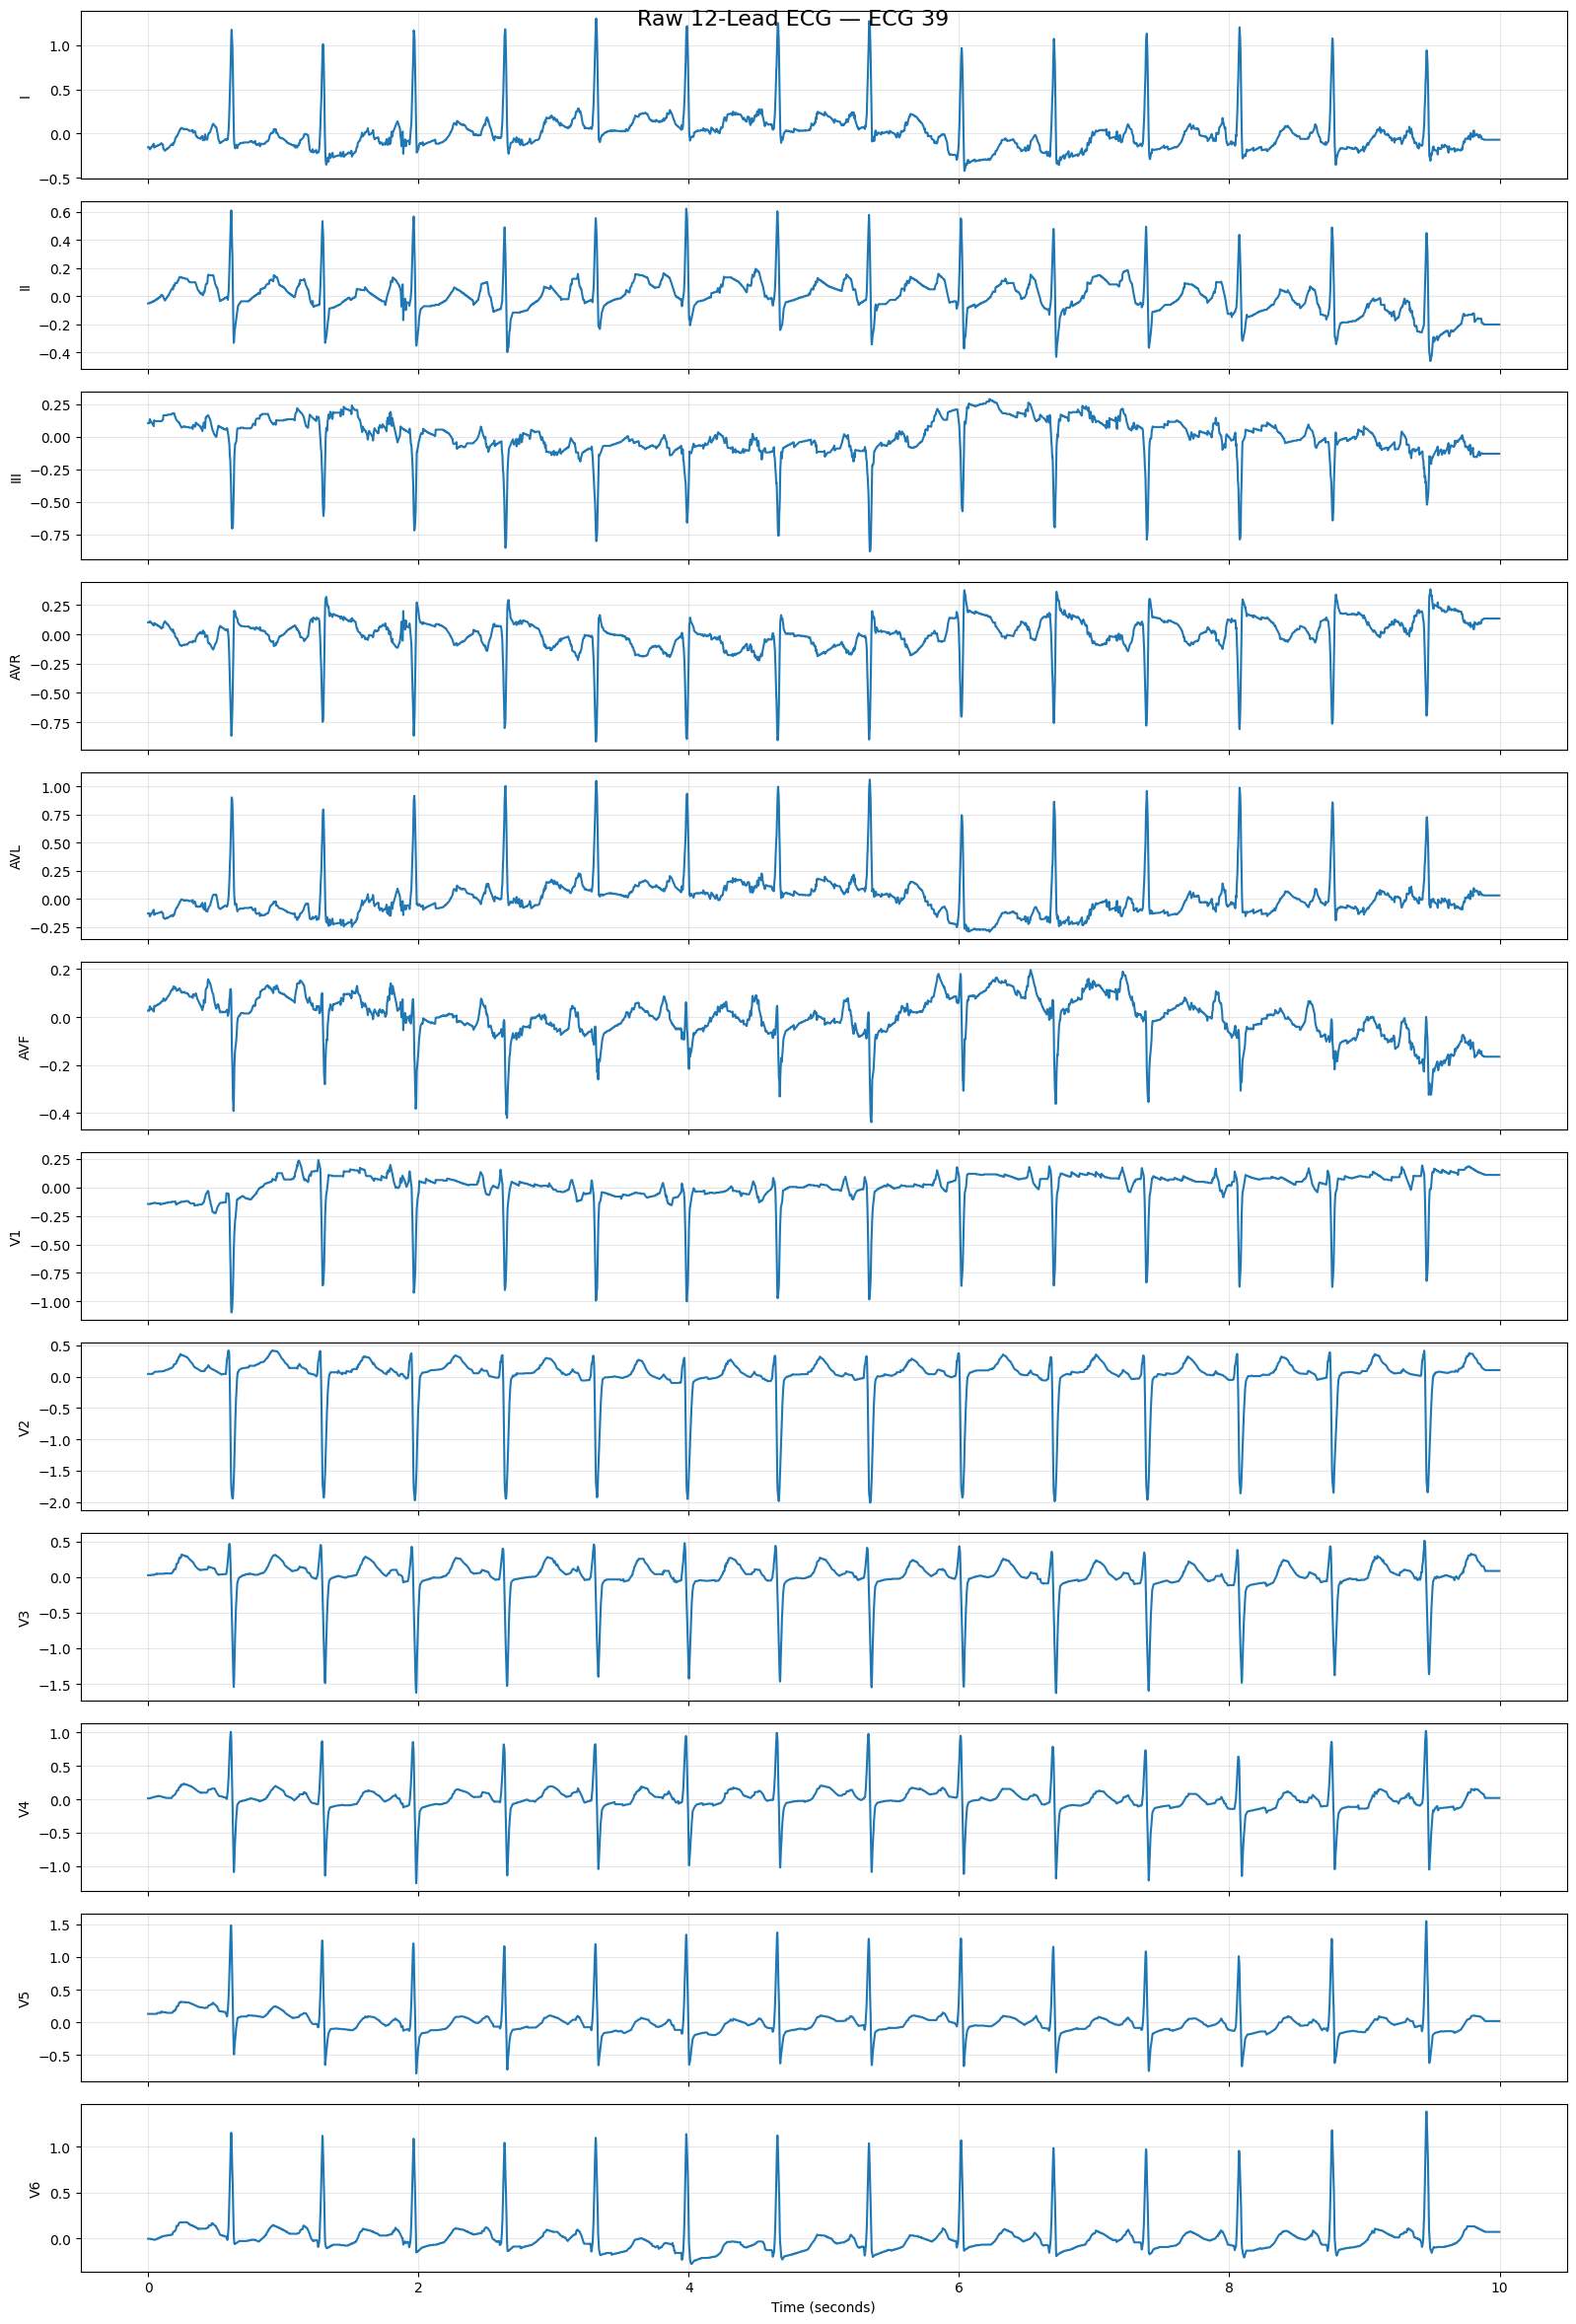

In [13]:
# ============================================================
# Cell 10 — Raw 12-Lead ECG Visualization
# ============================================================

time = np.arange(ecg_signal.shape[0]) / sampling_frequency

fig, axes = plt.subplots(
    12, 1,
    figsize=(16, 24),
    sharex=True
)

for i, lead in enumerate(lead_names):
    axes[i].plot(time, ecg_signal[:, i])
    axes[i].set_ylabel(lead)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")

fig.suptitle(
    f"Raw 12-Lead ECG — ECG {ecg_id}",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# Cell 11 — Baseline Wander Quantification
# ============================================================

from scipy import signal

# Estimate baseline using a low-pass Butterworth filter
baseline_cutoff = 0.5  # Hz

b, a = signal.butter(
    N=3,
    Wn=baseline_cutoff,
    btype="lowpass",
    fs=sampling_frequency
)

baseline = signal.filtfilt(
    b,
    a,
    ecg_signal,
    axis=0
)

# Calculate baseline amplitude for each lead
print("Baseline-wander statistics")
print("=" * 70)

for i, lead in enumerate(lead_names):

    baseline_lead = baseline[:, i]

    print(
        f"{lead:>4} | "
        f"Min: {np.min(baseline_lead):>8.4f} mV | "
        f"Max: {np.max(baseline_lead):>8.4f} mV | "
        f"Peak-to-peak: "
        f"{np.ptp(baseline_lead):>8.4f} mV"
    )

print("\nOverall baseline peak-to-peak:")
print(f"{np.ptp(baseline):.4f} mV")

Baseline-wander statistics
   I | Min:  -0.1440 mV | Max:   0.1665 mV | Peak-to-peak:   0.3105 mV
  II | Min:  -0.1521 mV | Max:   0.0641 mV | Peak-to-peak:   0.2162 mV
 III | Min:  -0.1166 mV | Max:   0.1637 mV | Peak-to-peak:   0.2803 mV
 AVR | Min:  -0.1118 mV | Max:   0.1087 mV | Peak-to-peak:   0.2205 mV
 AVL | Min:  -0.1539 mV | Max:   0.1407 mV | Peak-to-peak:   0.2945 mV
 AVF | Min:  -0.1194 mV | Max:   0.0915 mV | Peak-to-peak:   0.2109 mV
  V1 | Min:  -0.1603 mV | Max:   0.0749 mV | Peak-to-peak:   0.2352 mV
  V2 | Min:  -0.0692 mV | Max:   0.0901 mV | Peak-to-peak:   0.1593 mV
  V3 | Min:  -0.0657 mV | Max:   0.0689 mV | Peak-to-peak:   0.1346 mV
  V4 | Min:  -0.0778 mV | Max:   0.0698 mV | Peak-to-peak:   0.1476 mV
  V5 | Min:  -0.0522 mV | Max:   0.1988 mV | Peak-to-peak:   0.2510 mV
  V6 | Min:  -0.0855 mV | Max:   0.0844 mV | Peak-to-peak:   0.1699 mV

Overall baseline peak-to-peak:
0.3591 mV


In [15]:
# ============================================================
# Cell 12 — High-Frequency Noise Quantification
# ============================================================

# Estimate high-frequency component
# Frequencies above 40 Hz are used only for noise assessment here.
noise_cutoff = 40.0

b_noise, a_noise = signal.butter(
    N=3,
    Wn=noise_cutoff,
    btype="highpass",
    fs=sampling_frequency
)

high_freq_component = signal.filtfilt(
    b_noise,
    a_noise,
    ecg_signal,
    axis=0
)

print("High-frequency component statistics")
print("=" * 70)

for i, lead in enumerate(lead_names):

    noise_lead = high_freq_component[:, i]

    rms_noise = np.sqrt(np.mean(noise_lead ** 2))

    print(
        f"{lead:>4} | "
        f"RMS: {rms_noise:>8.5f} mV | "
        f"Peak-to-peak: {np.ptp(noise_lead):>8.5f} mV"
    )

print("\nHighest estimated high-frequency RMS noise:")

noise_rms = np.sqrt(np.mean(high_freq_component ** 2, axis=0))

highest_idx = np.argmax(noise_rms)

print(
    f"{lead_names[highest_idx]} "
    f"({noise_rms[highest_idx]:.5f} mV RMS)"
)

High-frequency component statistics
   I | RMS:  0.01334 mV | Peak-to-peak:  0.23323 mV
  II | RMS:  0.00867 mV | Peak-to-peak:  0.23096 mV
 III | RMS:  0.01047 mV | Peak-to-peak:  0.15320 mV
 AVR | RMS:  0.00997 mV | Peak-to-peak:  0.23207 mV
 AVL | RMS:  0.01118 mV | Peak-to-peak:  0.15958 mV
 AVF | RMS:  0.00691 mV | Peak-to-peak:  0.11989 mV
  V1 | RMS:  0.00932 mV | Peak-to-peak:  0.13974 mV
  V2 | RMS:  0.01756 mV | Peak-to-peak:  0.29663 mV
  V3 | RMS:  0.01305 mV | Peak-to-peak:  0.21572 mV
  V4 | RMS:  0.01617 mV | Peak-to-peak:  0.30187 mV
  V5 | RMS:  0.01621 mV | Peak-to-peak:  0.27336 mV
  V6 | RMS:  0.01000 mV | Peak-to-peak:  0.18402 mV

Highest estimated high-frequency RMS noise:
V2 (0.01756 mV RMS)


In [16]:
# ============================================================
# Cell 13 — Conservative ECG Band-Pass Filter
# ============================================================

low_cutoff = 0.5      # Hz
high_cutoff = 40.0    # Hz
filter_order = 4

# Design Butterworth band-pass filter
b_band, a_band = signal.butter(
    filter_order,
    [low_cutoff, high_cutoff],
    btype="bandpass",
    fs=sampling_frequency
)

# Apply zero-phase filtering
ecg_filtered = signal.filtfilt(
    b_band,
    a_band,
    ecg_signal,
    axis=0
)

print("Filtering completed successfully.")

print("\nFilter configuration:")
print(f"Type: Butterworth band-pass")
print(f"Order: {filter_order}")
print(f"Low cutoff: {low_cutoff} Hz")
print(f"High cutoff: {high_cutoff} Hz")
print("Phase: Zero-phase (filtfilt)")

print("\nOriginal shape:", ecg_signal.shape)
print("Filtered shape:", ecg_filtered.shape)

print("\nOriginal range:")
print(
    f"{np.min(ecg_signal):.4f} to "
    f"{np.max(ecg_signal):.4f} mV"
)

print("Filtered range:")
print(
    f"{np.min(ecg_filtered):.4f} to "
    f"{np.max(ecg_filtered):.4f} mV"
)

Filtering completed successfully.

Filter configuration:
Type: Butterworth band-pass
Order: 4
Low cutoff: 0.5 Hz
High cutoff: 40.0 Hz
Phase: Zero-phase (filtfilt)

Original shape: (5000, 12)
Filtered shape: (5000, 12)

Original range:
-2.0110 to 1.5450 mV
Filtered range:
-2.1008 to 1.4441 mV


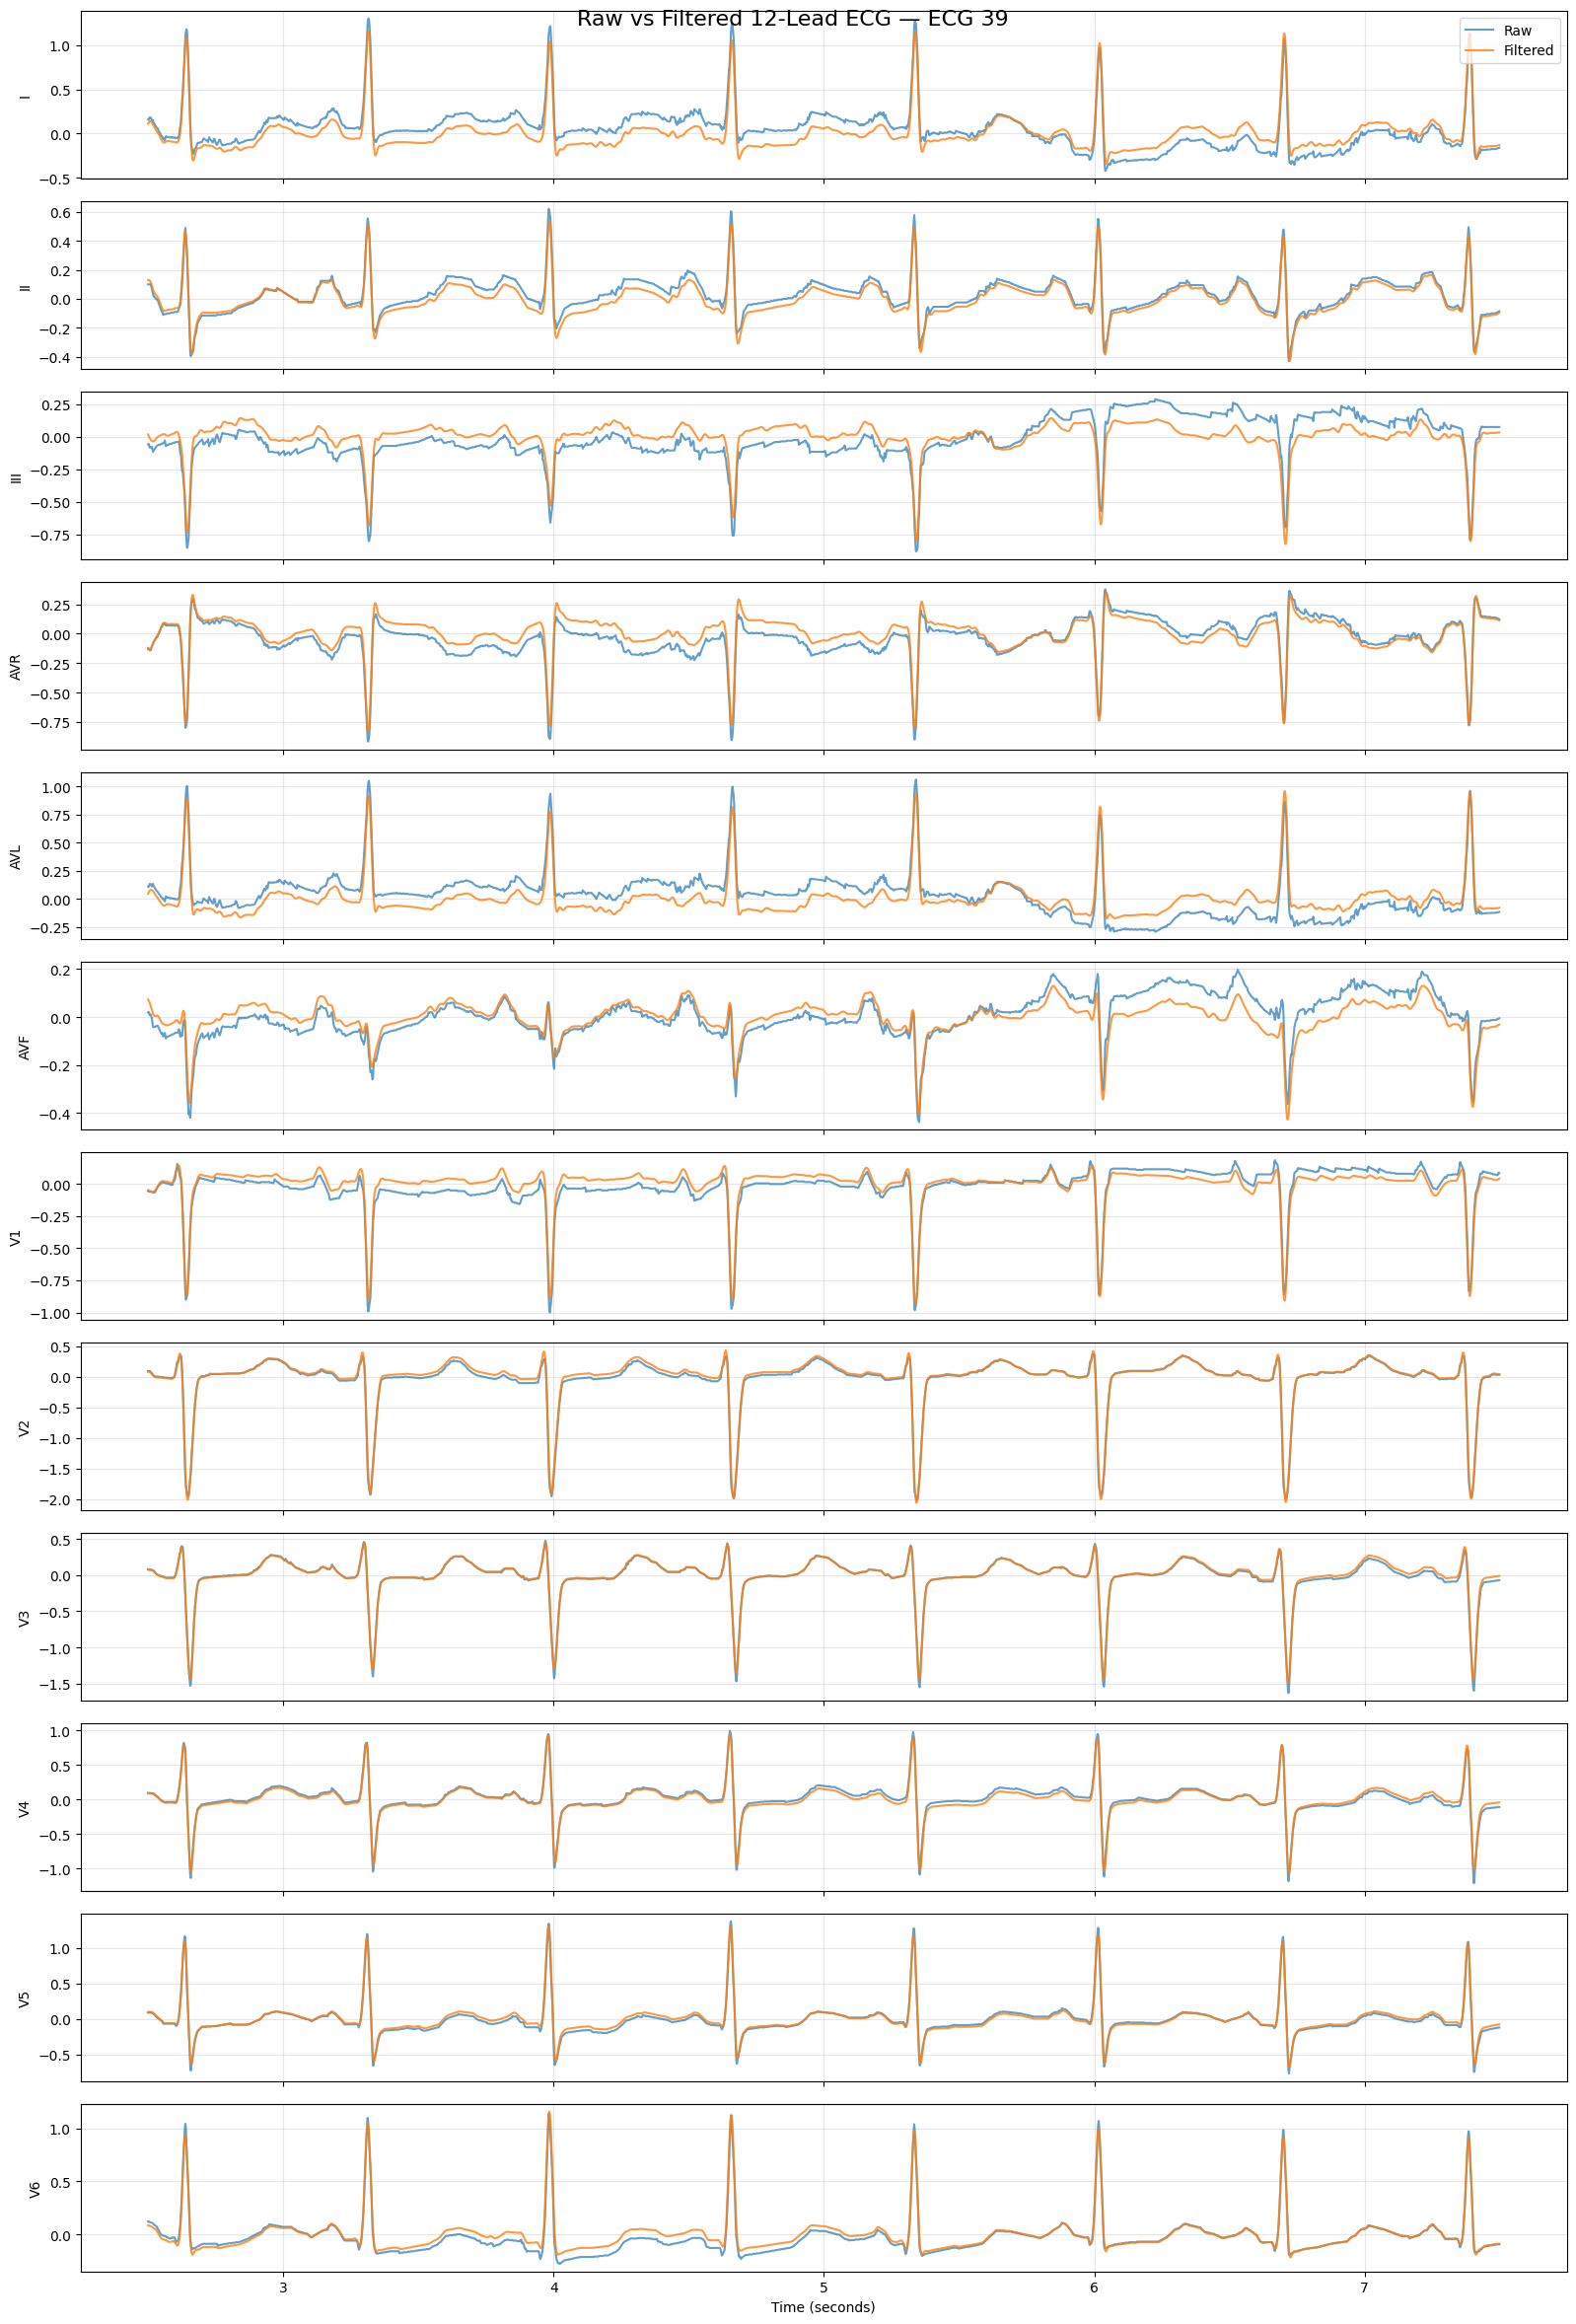

In [17]:
# ============================================================
# Cell 14 — Raw vs Filtered ECG Comparison
# ============================================================

# Show the middle 5 seconds to avoid emphasizing edge effects
start_sample = int(2.5 * sampling_frequency)
end_sample = int(7.5 * sampling_frequency)

time_window = time[start_sample:end_sample]

fig, axes = plt.subplots(
    12, 1,
    figsize=(16, 24),
    sharex=True
)

for i, lead in enumerate(lead_names):

    axes[i].plot(
        time_window,
        ecg_signal[start_sample:end_sample, i],
        label="Raw",
        alpha=0.7
    )

    axes[i].plot(
        time_window,
        ecg_filtered[start_sample:end_sample, i],
        label="Filtered",
        alpha=0.8
    )

    axes[i].set_ylabel(lead)
    axes[i].grid(True, alpha=0.3)

    if i == 0:
        axes[i].legend(loc="upper right")

axes[-1].set_xlabel("Time (seconds)")

fig.suptitle(
    f"Raw vs Filtered 12-Lead ECG — ECG {ecg_id}",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# Cell 15 — Quantitative Raw vs Filtered Validation
# ============================================================

from scipy.stats import pearsonr

comparison_results = []

for i, lead in enumerate(lead_names):

    raw = ecg_signal[:, i]
    filtered = ecg_filtered[:, i]

    # Correlation between raw and filtered signals
    correlation, _ = pearsonr(raw, filtered)

    # RMS amplitudes
    raw_rms = np.sqrt(np.mean(raw ** 2))
    filtered_rms = np.sqrt(np.mean(filtered ** 2))

    # Difference introduced by filtering
    difference = raw - filtered

    difference_rms = np.sqrt(np.mean(difference ** 2))
    max_difference = np.max(np.abs(difference))

    # RMS percentage change
    rms_change_percent = (
        (filtered_rms - raw_rms) / raw_rms
    ) * 100

    comparison_results.append({
        "Lead": lead,
        "Correlation": correlation,
        "Raw_RMS_mV": raw_rms,
        "Filtered_RMS_mV": filtered_rms,
        "Difference_RMS_mV": difference_rms,
        "Max_Difference_mV": max_difference,
        "RMS_Change_%": rms_change_percent
    })

comparison_df = pd.DataFrame(comparison_results)

print("Raw vs Filtered Quantitative Comparison")
print("=" * 100)

display(
    comparison_df.style.format({
        "Correlation": "{:.5f}",
        "Raw_RMS_mV": "{:.5f}",
        "Filtered_RMS_mV": "{:.5f}",
        "Difference_RMS_mV": "{:.5f}",
        "Max_Difference_mV": "{:.5f}",
        "RMS_Change_%": "{:.2f}"
    })
)

Raw vs Filtered Quantitative Comparison


,Lead,Correlation,Raw_RMS_mV,Filtered_RMS_mV,Difference_RMS_mV,Max_Difference_mV,RMS_Change_%
0,I,0.90027,0.21638,0.19299,0.09424,0.23837,-10.81
1,II,0.86746,0.12896,0.11095,0.06433,0.24004,-13.97
2,III,0.81421,0.15465,0.12369,0.08985,0.21591,-20.02
3,AVR,0.90901,0.16038,0.14470,0.06693,0.17896,-9.78
4,AVL,0.87263,0.17660,0.15222,0.08627,0.22199,-13.80
5,AVF,0.74065,0.09239,0.06692,0.06218,0.18044,-27.57
6,V1,0.91504,0.16707,0.15124,0.06741,0.16733,-9.47
7,V2,0.99211,0.38684,0.38297,0.04886,0.20775,-1.00
8,V3,0.98835,0.26401,0.26048,0.04020,0.16815,-1.33
9,V4,0.97839,0.21727,0.21135,0.04494,0.22008,-2.73


In [19]:
# ============================================================
# Cell 16 — R-Peak Preservation: Raw vs Filtered
# ============================================================

from scipy.signal import find_peaks

lead_name = "II"
lead_idx = lead_names.index(lead_name)

raw_lead = ecg_signal[:, lead_idx]
filtered_lead = ecg_filtered[:, lead_idx]

# Minimum distance between R-peaks:
# 0.4 seconds = maximum theoretical heart rate of 150 bpm
min_distance = int(0.4 * sampling_frequency)

# Detect peaks in raw signal
raw_peaks, raw_properties = find_peaks(
    raw_lead,
    distance=min_distance,
    prominence=0.15
)

# Detect peaks in filtered signal
filtered_peaks, filtered_properties = find_peaks(
    filtered_lead,
    distance=min_distance,
    prominence=0.15
)

print("R-Peak Detection Comparison")
print("=" * 60)

print(f"Lead: {lead_name}")
print(f"Raw peaks detected:      {len(raw_peaks)}")
print(f"Filtered peaks detected: {len(filtered_peaks)}")

print("\nRaw peak locations:")
print(raw_peaks)

print("\nFiltered peak locations:")
print(filtered_peaks)

R-Peak Detection Comparison
Lead: II
Raw peaks detected:      14
Filtered peaks detected: 14

Raw peak locations:
[ 308  645  983 1319 1656 1991 2328 2667 3007 3350 3692 4037 4380 4730]

Filtered peak locations:
[ 307  645  982 1319 1657 1992 2328 2667 3008 3349 3692 4037 4381 4730]


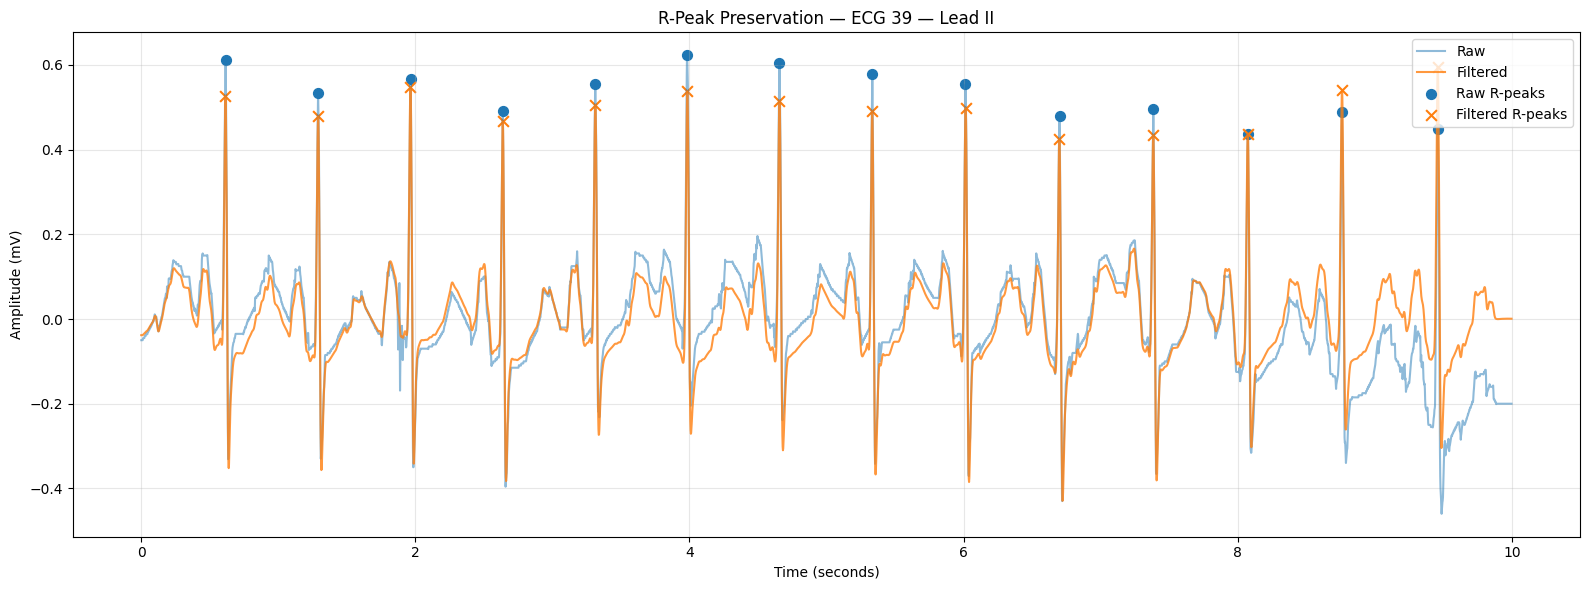

In [20]:
# ============================================================
# Cell 17 — Visual R-Peak Alignment
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(
    time,
    raw_lead,
    alpha=0.5,
    label="Raw"
)

plt.plot(
    time,
    filtered_lead,
    alpha=0.8,
    label="Filtered"
)

plt.scatter(
    time[raw_peaks],
    raw_lead[raw_peaks],
    marker="o",
    s=50,
    label="Raw R-peaks"
)

plt.scatter(
    time[filtered_peaks],
    filtered_lead[filtered_peaks],
    marker="x",
    s=60,
    label="Filtered R-peaks"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.title(f"R-Peak Preservation — ECG {ecg_id} — Lead {lead_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# Cell 18 — Quantitative R-Peak Timing Preservation
# ============================================================

# Make sure both arrays have the same number of detected peaks
n_peaks = min(len(raw_peaks), len(filtered_peaks))

raw_peaks_matched = raw_peaks[:n_peaks]
filtered_peaks_matched = filtered_peaks[:n_peaks]

# Difference in samples
peak_difference_samples = (
    filtered_peaks_matched - raw_peaks_matched
)

# Convert samples to milliseconds
peak_difference_ms = (
    peak_difference_samples / sampling_frequency * 1000
)

print("R-Peak Timing Preservation")
print("=" * 60)

print(f"Number of matched peaks: {n_peaks}")

print("\nPeak differences (samples):")
print(peak_difference_samples)

print("\nPeak differences (milliseconds):")
print(np.round(peak_difference_ms, 3))

print("\nSummary:")
print(f"Mean difference:      {np.mean(peak_difference_ms):.3f} ms")
print(f"Mean absolute error:  {np.mean(np.abs(peak_difference_ms)):.3f} ms")
print(f"Maximum absolute error: {np.max(np.abs(peak_difference_ms)):.3f} ms")
print(f"Standard deviation:   {np.std(peak_difference_ms):.3f} ms")

R-Peak Timing Preservation
Number of matched peaks: 14

Peak differences (samples):
[-1  0 -1  0  1  1  0  0  1 -1  0  0  1  0]

Peak differences (milliseconds):
[-2.  0. -2.  0.  2.  2.  0.  0.  2. -2.  0.  0.  2.  0.]

Summary:
Mean difference:      0.143 ms
Mean absolute error:  1.000 ms
Maximum absolute error: 2.000 ms
Standard deviation:   1.407 ms


In [24]:
# ============================================================
# Cell 19 — QRS Morphology Preservation
# ============================================================

qrs_window_before = int(0.08 * sampling_frequency)  # 80 ms
qrs_window_after = int(0.08 * sampling_frequency)   # 80 ms

raw_qrs_amplitudes = []
filtered_qrs_amplitudes = []

raw_qrs_ranges = []
filtered_qrs_ranges = []

for raw_peak, filtered_peak in zip(
    raw_peaks_matched,
    filtered_peaks_matched
):

    # Define QRS analysis windows
    raw_start = max(0, raw_peak - qrs_window_before)
    raw_end = min(len(raw_lead), raw_peak + qrs_window_after)

    filtered_start = max(
        0, filtered_peak - qrs_window_before
    )
    filtered_end = min(
        len(filtered_lead), filtered_peak + qrs_window_after
    )

    raw_segment = raw_lead[raw_start:raw_end]
    filtered_segment = filtered_lead[
        filtered_start:filtered_end
    ]

    # R-peak amplitudes
    raw_qrs_amplitudes.append(raw_lead[raw_peak])
    filtered_qrs_amplitudes.append(
        filtered_lead[filtered_peak]
    )

    # Peak-to-peak amplitude within QRS window
    raw_qrs_ranges.append(
        np.max(raw_segment) - np.min(raw_segment)
    )

    filtered_qrs_ranges.append(
        np.max(filtered_segment) -
        np.min(filtered_segment)
    )

# Convert to NumPy arrays
raw_qrs_amplitudes = np.array(raw_qrs_amplitudes)
filtered_qrs_amplitudes = np.array(
    filtered_qrs_amplitudes
)

raw_qrs_ranges = np.array(raw_qrs_ranges)
filtered_qrs_ranges = np.array(
    filtered_qrs_ranges
)

# ============================================================
# Results
# ============================================================

raw_r_mean = np.mean(raw_qrs_amplitudes)
filtered_r_mean = np.mean(filtered_qrs_amplitudes)

raw_range_mean = np.mean(raw_qrs_ranges)
filtered_range_mean = np.mean(filtered_qrs_ranges)

r_amplitude_change = filtered_r_mean - raw_r_mean
qrs_range_change = filtered_range_mean - raw_range_mean

r_amplitude_change_percent = (
    r_amplitude_change / raw_r_mean * 100
)

qrs_range_change_percent = (
    qrs_range_change / raw_range_mean * 100
)

print("QRS Morphology Preservation")
print("=" * 60)

print(f"Number of beats analyzed: {len(raw_qrs_amplitudes)}")

print("\nR-peak amplitude:")
print(f"Raw mean:      {raw_r_mean:.4f} mV")
print(f"Filtered mean: {filtered_r_mean:.4f} mV")

print("\nQRS amplitude range:")
print(f"Raw mean:      {raw_range_mean:.4f} mV")
print(f"Filtered mean: {filtered_range_mean:.4f} mV")

print("\nAmplitude change:")
print(f"R-peak mean change: {r_amplitude_change:.4f} mV")
print(
    f"R-peak percentage change: "
    f"{r_amplitude_change_percent:.2f}%"
)

print(
    f"QRS range mean change: "
    f"{qrs_range_change:.4f} mV"
)

print(
    f"QRS range percentage change: "
    f"{qrs_range_change_percent:.2f}%"
)

QRS Morphology Preservation
Number of beats analyzed: 14

R-peak amplitude:
Raw mean:      0.5339 mV
Filtered mean: 0.5003 mV

QRS amplitude range:
Raw mean:      0.8702 mV
Filtered mean: 0.8373 mV

Amplitude change:
R-peak mean change: -0.0336 mV
R-peak percentage change: -6.29%
QRS range mean change: -0.0329 mV
QRS range percentage change: -3.78%


In [25]:
# ============================================================
# Cell 20 — Representative ECG Validation Set
# ============================================================

np.random.seed(42)

validation_ecgs = []

target_names = ["NORM", "MI", "STTC", "CD", "HYP"]

for target in target_names:

    # ECGs positive for this target
    target_ecgs = targets[
        targets[target] == 1
    ].index

    # Keep only training ECGs
    target_ecgs = target_ecgs[
        split_df.loc[target_ecgs, "split"] == "train"
    ]

    # Randomly select up to 20 ECGs
    selected = np.random.choice(
        target_ecgs,
        size=min(20, len(target_ecgs)),
        replace=False
    )

    validation_ecgs.extend(selected)

validation_ecgs = sorted(
    list(set(validation_ecgs))
)

print("Representative validation set")
print("=" * 60)

print(f"Total ECGs selected: {len(validation_ecgs)}")

print("\nFirst 20 ECG IDs:")
print(validation_ecgs[:20])

Representative validation set
Total ECGs selected: 100

First 20 ECG IDs:
[np.int64(77), np.int64(455), np.int64(672), np.int64(991), np.int64(1028), np.int64(1162), np.int64(1317), np.int64(1319), np.int64(1392), np.int64(1404), np.int64(1418), np.int64(1587), np.int64(2219), np.int64(2300), np.int64(3094), np.int64(3477), np.int64(3517), np.int64(3560), np.int64(3701), np.int64(4400)]


In [28]:
# ============================================================
# BATCH VALIDATION SETUP
# ============================================================

import os
import pandas as pd
import numpy as np
import wfdb
from scipy import signal

# Dataset path
dataset_path = (
    "/content/drive/MyDrive/PTB-XL Research Project/"
    "data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
)

# Results path
results_path = (
    "/content/drive/MyDrive/PTB-XL Research Project/results"
)

# Load PTB-XL metadata
metadata_path = os.path.join(
    dataset_path,
    "ptbxl_database.csv"
)

metadata = pd.read_csv(
    metadata_path,
    index_col="ecg_id"
)

print("Dataset exists:", os.path.exists(dataset_path))
print("Metadata shape:", metadata.shape)
print("Metadata loaded successfully.")

Dataset exists: True
Metadata shape: (21799, 27)
Metadata loaded successfully.


In [30]:
# ============================================================
# BAND-PASS FILTER FUNCTION
# ============================================================

from scipy import signal
import numpy as np

def bandpass_filter(ecg_signal, fs=500, lowcut=0.5, highcut=40.0, order=4):
    """
    Apply a zero-phase Butterworth band-pass filter
    to a 12-lead ECG signal.

    Parameters
    ----------
    ecg_signal : numpy.ndarray
        ECG signal with shape (samples, leads)

    fs : int
        Sampling frequency in Hz

    lowcut : float
        Lower cutoff frequency in Hz

    highcut : float
        Upper cutoff frequency in Hz

    order : int
        Butterworth filter order

    Returns
    -------
    filtered_signal : numpy.ndarray
        Filtered ECG signal with same shape as input
    """

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = signal.butter(
        order,
        [low, high],
        btype="bandpass"
    )

    filtered_signal = signal.filtfilt(
        b,
        a,
        ecg_signal,
        axis=0
    )

    return filtered_signal


print("Band-pass filter function defined successfully.")

# Quick verification using the ECG already loaded in memory
if "ecg_signal" in globals():
    test_filtered = bandpass_filter(ecg_signal)

    print("Test filtering successful.")
    print("Original shape :", ecg_signal.shape)
    print("Filtered shape :", test_filtered.shape)

Band-pass filter function defined successfully.
Test filtering successful.
Original shape : (5000, 12)
Filtered shape : (5000, 12)


In [31]:
# ============================================================
# Cell 21 — Batch Filtering Validation
# ============================================================

# Re-establish the dataset path
dataset_path = (
    "/content/drive/MyDrive/PTB-XL Research Project/"
    "data/ptb-xl-a-large-publicly-available-"
    "electrocardiography-dataset-1.0.3"
)

print("Dataset exists:", os.path.exists(dataset_path))

filter_validation_results = []

print("\nRunning batch filtering validation...")
print("=" * 60)

for i, ecg_id in enumerate(validation_ecgs):

    try:
        # ----------------------------------------------------
        # Get high-resolution record path
        # ----------------------------------------------------

        filename = metadata.loc[
            ecg_id, "filename_hr"
        ]

        record_path = os.path.join(
            dataset_path,
            filename
        )

        # Verify record exists
        if not os.path.exists(record_path + ".hea"):
            raise FileNotFoundError(
                f"Header not found: {record_path}.hea"
            )

        # ----------------------------------------------------
        # Read ECG
        # ----------------------------------------------------

        record = wfdb.rdrecord(record_path)

        raw_signal = record.p_signal.astype(float)
        fs = record.fs

        # ----------------------------------------------------
        # Apply 0.5–40 Hz Butterworth band-pass filter
        # ----------------------------------------------------

        filtered_signal = bandpass_filter(
            raw_signal,
            fs=fs,
            lowcut=0.5,
            highcut=40.0,
            order=4
        )

        # ----------------------------------------------------
        # Quantitative comparison for every lead
        # ----------------------------------------------------

        for lead_idx, lead_name in enumerate(record.sig_name):

            raw = raw_signal[:, lead_idx]
            filtered = filtered_signal[:, lead_idx]

            correlation = np.corrcoef(
                raw,
                filtered
            )[0, 1]

            raw_rms = np.sqrt(
                np.mean(raw ** 2)
            )

            filtered_rms = np.sqrt(
                np.mean(filtered ** 2)
            )

            rms_difference = np.sqrt(
                np.mean((raw - filtered) ** 2)
            )

            max_difference = np.max(
                np.abs(raw - filtered)
            )

            filter_validation_results.append({
                "ecg_id": int(ecg_id),
                "lead": lead_name,
                "correlation": correlation,
                "raw_rms_mV": raw_rms,
                "filtered_rms_mV": filtered_rms,
                "rms_difference_mV": rms_difference,
                "max_difference_mV": max_difference
            })

        if (i + 1) % 10 == 0:
            print(
                f"Processed "
                f"{i + 1}/{len(validation_ecgs)} ECGs"
            )

    except Exception as e:

        print(
            f"ERROR — ECG {ecg_id}: {e}"
        )

# ------------------------------------------------------------
# Convert results to DataFrame
# ------------------------------------------------------------

filter_validation_df = pd.DataFrame(
    filter_validation_results
)

print("\nBatch validation completed.")
print(
    f"Rows generated: "
    f"{len(filter_validation_df)}"
)

print(
    f"Expected rows: "
    f"{len(validation_ecgs) * 12}"
)

# ------------------------------------------------------------
# Basic success check
# ------------------------------------------------------------

if len(filter_validation_df) == len(validation_ecgs) * 12:
    print("\n✓ All ECGs and leads processed successfully.")
else:
    print(
        "\n⚠ Some ECGs/leads were not processed."
    )

Dataset exists: True

Running batch filtering validation...
Processed 10/100 ECGs
Processed 20/100 ECGs
Processed 30/100 ECGs
Processed 40/100 ECGs
Processed 50/100 ECGs
Processed 60/100 ECGs
Processed 70/100 ECGs
Processed 80/100 ECGs
Processed 90/100 ECGs
Processed 100/100 ECGs

Batch validation completed.
Rows generated: 1200
Expected rows: 1200

✓ All ECGs and leads processed successfully.


In [34]:
# ============================================================
# CELL 22A — FIND BATCH RESULTS VARIABLE
# ============================================================

print("=" * 80)
print("SEARCHING FOR BATCH RESULTS")
print("=" * 80)

# Take a snapshot of the current variables first
current_variables = list(globals().items())

dataframe_variables = {}

for name, value in current_variables:
    try:
        if isinstance(value, pd.DataFrame):
            dataframe_variables[name] = value
    except Exception:
        pass


print("\nDataFrames currently in memory:")
print("-" * 80)

for name, df_temp in dataframe_variables.items():
    print(
        f"{name:30s} | "
        f"shape = {df_temp.shape}"
    )


# ============================================================
# FIND DATAFRAMES WITH 1200 ROWS
# ============================================================

print("\n" + "=" * 80)
print("POTENTIAL BATCH RESULT DATAFRAMES")
print("=" * 80)

found_candidates = []

for name, df_temp in dataframe_variables.items():

    if len(df_temp) == 1200:

        found_candidates.append(name)

        print(f"\n✓ Candidate: {name}")
        print(f"  Shape: {df_temp.shape}")
        print(f"  Columns: {df_temp.columns.tolist()}")

        print("\n  First 3 rows:")
        display(df_temp.head(3))


# ============================================================
# RESULT
# ============================================================

print("\n" + "=" * 80)
print("CANDIDATES FOUND")
print("=" * 80)

if len(found_candidates) == 0:

    print("⚠ No DataFrame with exactly 1200 rows was found.")

else:

    for candidate in found_candidates:
        print(f"✓ {candidate}")

SEARCHING FOR BATCH RESULTS

DataFrames currently in memory:
--------------------------------------------------------------------------------
df                             | shape = (21799, 27)
targets                        | shape = (21799, 7)
demographics_clean             | shape = (21799, 8)
split_df                       | shape = (21799, 3)
split_check                    | shape = (21799, 2)
comparison_df                  | shape = (12, 7)
filter_validation_df           | shape = (1200, 7)
metadata                       | shape = (21799, 27)

POTENTIAL BATCH RESULT DATAFRAMES

✓ Candidate: filter_validation_df
  Shape: (1200, 7)
  Columns: ['ecg_id', 'lead', 'correlation', 'raw_rms_mV', 'filtered_rms_mV', 'rms_difference_mV', 'max_difference_mV']

  First 3 rows:


,ecg_id,lead,correlation,raw_rms_mV,filtered_rms_mV,rms_difference_mV,max_difference_mV
0,77,I,0.960510,0.141349,0.135560,0.039342,0.115044
1,77,II,0.928398,0.180825,0.166767,0.067197,0.242642
2,77,III,0.729775,0.081819,0.058148,0.055963,0.242473



CANDIDATES FOUND
✓ filter_validation_df


In [35]:
# ============================================================
# CELL 22 — BATCH FILTERING STATISTICAL ANALYSIS
# ============================================================

print("=" * 80)
print("BATCH FILTERING STATISTICAL ANALYSIS")
print("=" * 80)

# Use the validated 100-ECG batch results
batch_df = filter_validation_df.copy()

print(f"\nTotal rows: {len(batch_df)}")
print(f"Unique ECGs: {batch_df['ecg_id'].nunique()}")
print(f"Unique leads: {batch_df['lead'].nunique()}")

# ============================================================
# CALCULATE RMS CHANGE (%)
# ============================================================

batch_df["rms_change_percent"] = (
    (batch_df["filtered_rms_mV"] - batch_df["raw_rms_mV"])
    / batch_df["raw_rms_mV"]
) * 100

# ============================================================
# CORRELATION STATISTICS BY LEAD
# ============================================================

print("\n" + "=" * 80)
print("CORRELATION STATISTICS BY LEAD")
print("=" * 80)

correlation_summary = (
    batch_df
    .groupby("lead")["correlation"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .round(4)
)

display(correlation_summary)

# ============================================================
# RMS CHANGE STATISTICS BY LEAD
# ============================================================

print("\n" + "=" * 80)
print("RMS CHANGE STATISTICS BY LEAD")
print("=" * 80)

rms_summary = (
    batch_df
    .groupby("lead")["rms_change_percent"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .round(2)
)

display(rms_summary)

# ============================================================
# RMS DIFFERENCE BY LEAD
# ============================================================

print("\n" + "=" * 80)
print("RMS DIFFERENCE BY LEAD")
print("=" * 80)

rms_difference_summary = (
    batch_df
    .groupby("lead")["rms_difference_mV"]
    .agg([
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .round(5)
)

display(rms_difference_summary)

# ============================================================
# OVERALL STATISTICS
# ============================================================

print("\n" + "=" * 80)
print("OVERALL FILTER PERFORMANCE")
print("=" * 80)

print("\nCorrelation:")
print(f"Mean   : {batch_df['correlation'].mean():.4f}")
print(f"Median : {batch_df['correlation'].median():.4f}")
print(f"Std    : {batch_df['correlation'].std():.4f}")
print(f"Min    : {batch_df['correlation'].min():.4f}")
print(f"Max    : {batch_df['correlation'].max():.4f}")

print("\nRMS change:")
print(f"Mean   : {batch_df['rms_change_percent'].mean():.2f}%")
print(f"Median : {batch_df['rms_change_percent'].median():.2f}%")
print(f"Std    : {batch_df['rms_change_percent'].std():.2f}%")
print(f"Min    : {batch_df['rms_change_percent'].min():.2f}%")
print(f"Max    : {batch_df['rms_change_percent'].max():.2f}%")

# ============================================================
# LOW-CORRELATION CASES
# ============================================================

print("\n" + "=" * 80)
print("LOW-CORRELATION CASES")
print("=" * 80)

low_correlation = batch_df[
    batch_df["correlation"] < 0.80
].copy()

print(
    f"Records with correlation < 0.80: "
    f"{len(low_correlation)} / {len(batch_df)}"
)

if len(low_correlation) > 0:

    print("\nLowest-correlation cases:")

    display(
        low_correlation
        .sort_values("correlation")
        .head(20)
    )

else:

    print("✓ No records had correlation below 0.80.")

# ============================================================
# HIGH-CORRELATION CASES
# ============================================================

print("\n" + "=" * 80)
print("HIGH-CORRELATION PERFORMANCE")
print("=" * 80)

for threshold in [0.90, 0.95, 0.98]:

    count = (batch_df["correlation"] >= threshold).sum()
    percentage = (count / len(batch_df)) * 100

    print(
        f"Correlation >= {threshold:.2f}: "
        f"{count}/{len(batch_df)} "
        f"({percentage:.2f}%)"
    )

# ============================================================
# SAVE RESULTS
# ============================================================

batch_results_path = os.path.join(
    results_path,
    "ptbxl_batch_filtering_analysis.csv"
)

batch_df.to_csv(
    batch_results_path,
    index=False
)

print("\n" + "=" * 80)
print("RESULTS SAVED")
print("=" * 80)

print(batch_results_path)
print(f"File exists: {os.path.exists(batch_results_path)}")

BATCH FILTERING STATISTICAL ANALYSIS

Total rows: 1200
Unique ECGs: 100
Unique leads: 12

CORRELATION STATISTICS BY LEAD


,count,mean,median,std,min,max
lead,,,,,,
AVF,100,0.8791,0.9414,0.1530,0.2675,0.9986
AVL,100,0.8978,0.9654,0.1454,0.2521,0.9989
AVR,100,0.9272,0.9716,0.1002,0.4477,0.9987
I,100,0.9306,0.9767,0.1128,0.4164,0.9987
II,100,0.9135,0.9612,0.1184,0.4411,0.9981
III,100,0.8692,0.9480,0.1691,0.2249,0.9984
V1,100,0.9385,0.9783,0.1030,0.4610,0.9995
V2,100,0.9397,0.9795,0.1228,0.3538,0.9995
V3,100,0.9443,0.9802,0.1061,0.4903,0.9993



RMS CHANGE STATISTICS BY LEAD


,count,mean,median,std,min,max
lead,,,,,,
AVF,100,-12.07,-5.74,16.06,-74.13,7.90
AVL,100,-10.19,-4.03,15.75,-79.28,18.02
AVR,100,-6.21,-2.47,10.80,-55.38,25.63
I,100,-6.44,-2.47,12.33,-58.04,24.48
II,100,-7.47,-3.32,12.31,-52.28,18.81
III,100,-13.56,-5.90,18.22,-77.50,8.82
V1,100,-5.41,-2.10,10.83,-53.07,19.14
V2,100,-4.54,-1.36,11.55,-64.40,14.89
V3,100,-4.73,-1.70,10.84,-51.19,13.99



RMS DIFFERENCE BY LEAD


,mean,median,std,min,max
lead,,,,,
AVF,0.04645,0.03269,0.03852,0.00747,0.19229
AVL,0.04535,0.03165,0.04809,0.00703,0.27803
AVR,0.04375,0.02802,0.03906,0.00856,0.19985
I,0.04890,0.03046,0.05412,0.00969,0.28077
II,0.05072,0.03483,0.04233,0.00855,0.20062
III,0.05516,0.03904,0.05058,0.00774,0.27689
V1,0.05284,0.03081,0.06135,0.00660,0.41421
V2,0.07581,0.04714,0.08636,0.01261,0.56262
V3,0.07351,0.04629,0.07108,0.01215,0.41292



OVERALL FILTER PERFORMANCE

Correlation:
Mean   : 0.9199
Median : 0.9714
Std    : 0.1261
Min    : 0.0846
Max    : 0.9995

RMS change:
Mean   : -7.26%
Median : -2.72%
Std    : 13.26%
Min    : -79.28%
Max    : 31.86%

LOW-CORRELATION CASES
Records with correlation < 0.80: 142 / 1200

Lowest-correlation cases:


,ecg_id,lead,correlation,raw_rms_mV,filtered_rms_mV,rms_difference_mV,max_difference_mV,rms_change_percent
142,1587,V5,0.084567,0.569595,0.409417,0.673077,3.702300,-28.121338
326,6348,III,0.224870,0.181947,0.040944,0.177333,0.352029,-77.496908
1084,19852,AVL,0.252137,0.286987,0.059454,0.278029,0.731896,-79.283334
329,6348,AVF,0.267491,0.168800,0.043666,0.162617,0.324915,-74.131582
1082,19852,III,0.285913,0.288396,0.065699,0.276890,0.726995,-77.219161
77,1317,AVF,0.304583,0.201810,0.056441,0.192291,0.404609,-72.032812
74,1317,III,0.343863,0.204266,0.062340,0.191959,0.364488,-69.480779
550,10080,V5,0.349886,0.342827,0.116474,0.321176,0.656576,-66.025583
823,15690,V2,0.353770,0.357706,0.127330,0.334575,0.855937,-64.403737
163,2300,V2,0.356454,0.601881,0.228189,0.562623,1.246348,-62.087336



HIGH-CORRELATION PERFORMANCE
Correlation >= 0.90: 923/1200 (76.92%)
Correlation >= 0.95: 758/1200 (63.17%)
Correlation >= 0.98: 480/1200 (40.00%)

RESULTS SAVED
/content/drive/MyDrive/PTB-XL Research Project/results/ptbxl_batch_filtering_analysis.csv
File exists: True


In [46]:
# ============================================================
# LOW-CORRELATION ECG INVESTIGATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import os

print("=" * 80)
print("LOW-CORRELATION ECG INVESTIGATION")
print("=" * 80)

# Load batch results if not already available
if "filter_validation_df" not in globals():
    analysis_path = os.path.join(
        results_path,
        "ptbxl_batch_filtering_analysis.csv"
    )
    filter_validation_df = pd.read_csv(analysis_path)

# Select the lowest-correlation cases
low_corr = (
    filter_validation_df
    .sort_values("correlation")
    .head(10)
    .copy()
)

print(f"\nLowest-correlation cases:")
print(low_corr[
    [
        "ecg_id",
        "lead",
        "correlation",
        "raw_rms_mV",
        "filtered_rms_mV",
        "rms_difference_mV",
        "max_difference_mV"
    ]
].to_string(index=False))

print("\n" + "=" * 80)
print("ECGs represented in the lowest-correlation cases")
print("=" * 80)

print(low_corr["ecg_id"].unique())

LOW-CORRELATION ECG INVESTIGATION

Lowest-correlation cases:
 ecg_id lead  correlation  raw_rms_mV  filtered_rms_mV  rms_difference_mV  max_difference_mV
   1587   V5     0.084567    0.569595         0.409417           0.673077           3.702300
   6348  III     0.224870    0.181947         0.040944           0.177333           0.352029
  19852  AVL     0.252137    0.286987         0.059454           0.278029           0.731896
   6348  AVF     0.267491    0.168800         0.043666           0.162617           0.324915
  19852  III     0.285913    0.288396         0.065699           0.276890           0.726995
   1317  AVF     0.304583    0.201810         0.056441           0.192291           0.404609
   1317  III     0.343863    0.204266         0.062340           0.191959           0.364488
  10080   V5     0.349886    0.342827         0.116474           0.321176           0.656576
  15690   V2     0.353770    0.357706         0.127330           0.334575           0.855937
   2300  

Investigating ECG ID: 1587
Metadata row found successfully.
Record identifier: records500/01000/01587_hr
Full record path:
/content/drive/MyDrive/PTB-XL Research Project/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records500/01000/01587_hr

Record files:
Header exists: True
Signal exists: True

ECG loaded successfully.
Sampling frequency: 500
Signal shape: (5000, 12)
Leads: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

Problematic lead: V5
Correlation: 0.08456745780932633


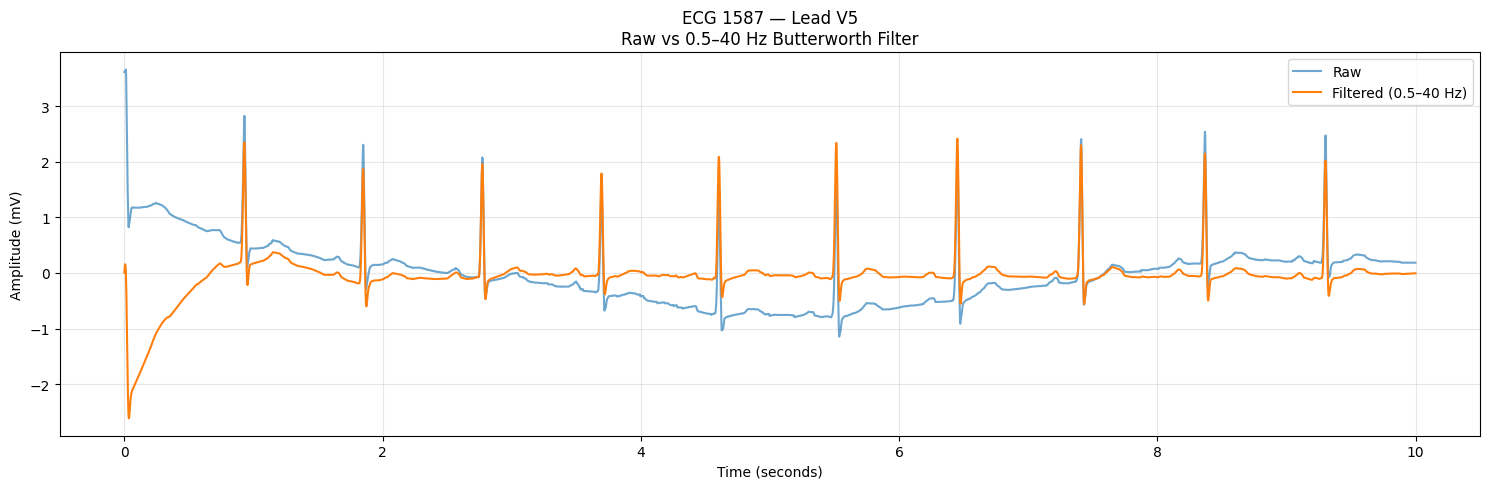

In [47]:
# ============================================================
# VISUALIZE LOW-CORRELATION CASE — ROBUST VERSION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import os

# ECG to investigate
ecg_id = int(low_corr.iloc[0]["ecg_id"])

print(f"Investigating ECG ID: {ecg_id}")
print("=" * 80)

# ------------------------------------------------------------
# Find metadata row
# ------------------------------------------------------------

if "ecg_id" in metadata.columns:

    row = metadata.loc[
        metadata["ecg_id"] == ecg_id
    ].iloc[0]

else:

    # ECG ID is stored as the index
    row = metadata.loc[ecg_id]

print("Metadata row found successfully.")

# ------------------------------------------------------------
# Get high-resolution record path
# ------------------------------------------------------------

record_path = row["filename_hr"]

print(f"Record identifier: {record_path}")

# Construct full path
if not os.path.isabs(record_path):
    record_path = os.path.join(
        dataset_path,
        record_path
    )

# Remove extensions if present
record_path = (
    str(record_path)
    .replace(".hea", "")
    .replace(".dat", "")
)

print(f"Full record path:")
print(record_path)

# ------------------------------------------------------------
# Verify files
# ------------------------------------------------------------

print("\nRecord files:")

print(
    "Header exists:",
    os.path.exists(record_path + ".hea")
)

print(
    "Signal exists:",
    os.path.exists(record_path + ".dat")
)

# ------------------------------------------------------------
# Load ECG
# ------------------------------------------------------------

record = wfdb.rdrecord(record_path)

raw_signal = record.p_signal
fs = record.fs
lead_names = record.sig_name

print("\nECG loaded successfully.")
print("Sampling frequency:", fs)
print("Signal shape:", raw_signal.shape)
print("Leads:", lead_names)

# ------------------------------------------------------------
# Apply the same filter used in batch validation
# ------------------------------------------------------------

filtered_signal = bandpass_filter(
    raw_signal,
    fs,
    lowcut=0.5,
    highcut=40.0,
    order=4
)

# ------------------------------------------------------------
# Identify problematic lead
# ------------------------------------------------------------

problem_lead = low_corr.iloc[0]["lead"]

lead_index = lead_names.index(problem_lead)

print("\nProblematic lead:", problem_lead)

print(
    "Correlation:",
    low_corr.iloc[0]["correlation"]
)

# ------------------------------------------------------------
# Time axis
# ------------------------------------------------------------

time = np.arange(
    raw_signal.shape[0]
) / fs

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    raw_signal[:, lead_index],
    label="Raw",
    alpha=0.65
)

plt.plot(
    time,
    filtered_signal[:, lead_index],
    label="Filtered (0.5–40 Hz)",
    linewidth=1.5
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")

plt.title(
    f"ECG {ecg_id} — Lead {problem_lead}\n"
    f"Raw vs 0.5–40 Hz Butterworth Filter"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()